In [33]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score


In [34]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

In [35]:
# csv파일이 데이터가 큰데 샘플을 10000개 행만 뽑아서 저장
df = pd.read_csv('../data/감자_월차_학습용.csv', encoding='cp949')

# 등급코드 제거
df = df.drop(columns=['등급코드'], errors='ignore')

# y, X 분리
y = df['평균단가(원)']
X = df.drop(columns=['평균단가(원)'])

# 날짜 처리
X['week_start'] = pd.to_datetime(X['week_start'])
X['year'] = X['week_start'].dt.year


In [36]:
# 학습용: 2024년까지
X_train = X[X['year'] < 2025].drop(columns=['week_start'])
y_train = y[X['year'] < 2025]

# 예측용: 2025년
X_test = X[X['year'] == 2025].drop(columns=['week_start'])
y_test = y[X['year'] == 2025]

print(f"학습 데이터 크기: {X_train.shape}")
print(f"예측 데이터 크기: {X_test.shape}")


학습 데이터 크기: (152432, 197)
예측 데이터 크기: (7581, 197)


In [37]:
param_distributions = {
    'n_estimators': [300, 500, 800],
    'max_depth': [8, 10, 12, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 0.5, 0.8],
    'min_impurity_decrease': [0.0, 0.01],
    'bootstrap': [True]
}


In [38]:
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_distributions,
    n_iter=20,
    scoring='neg_root_mean_squared_error',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)


Fitting 3 folds for each of 20 candidates, totalling 60 fits


KeyboardInterrupt: 

In [ ]:
# 최적 모델 추출
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)

# 평가 지표 출력
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("✅ 최적 하이퍼파라미터:", random_search.best_params_)
print(f"📉 2025년 RMSE: {rmse:.2f}")
print(f"📈 2025년 R² Score: {r2:.4f}")


ValueError: Found array with 0 sample(s) (shape=(0, 197)) while a minimum of 1 is required by RandomForestRegressor.

In [ ]:
X['week_start'] = pd.to_datetime(X['week_start'])  # 필수


In [ ]:
X['year'] = X['week_start'].dt.year


In [ ]:
print(X['year'].value_counts())     # 2025년 건수 확인
print(X[X['year'] == 2025].shape)   # 실제 분리 후 크기 확인


year
2018    10000
Name: count, dtype: int64
(0, 198)


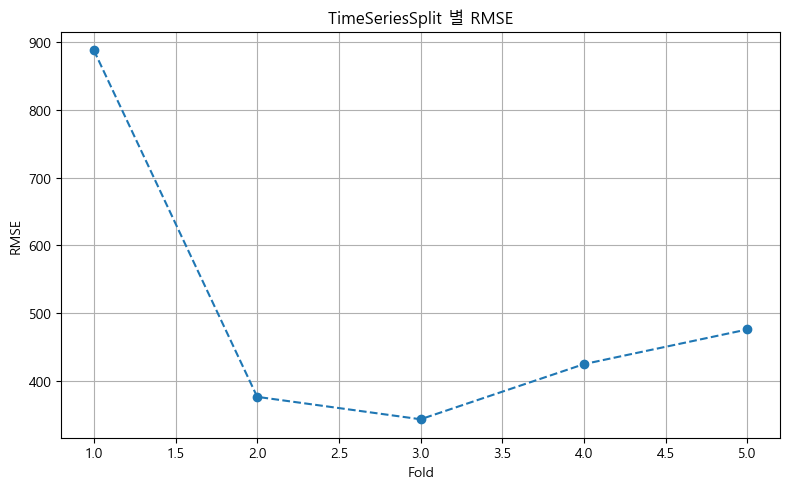

In [ ]:
# plt.figure(figsize=(8, 5))
# plt.plot(range(1, len(rmse_scores)+1), rmse_scores, marker='o', linestyle='--')
# plt.title("TimeSeriesSplit 별 RMSE")
# plt.xlabel("Fold")
# plt.ylabel("RMSE")
# plt.grid(True)
# plt.tight_layout()
# plt.show()
